<h1 style="text-align:center;">BPE Tokenization</h1>

**Table of contents**<a id='toc0_'></a>    
- [Hexadecimal representation](#toc1_1_)    
- [UTF-8 encoding](#toc1_2_)    
	- [Some Unicode vocab](#toc1_2_1_)    
    - [WTF is UTF-8 ?](#toc1_2_2_)    
    - [A sentence example](#toc1_2_3_)    
- [BPE Tokenization [WIP]](#toc1_3_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## <a id='toc1_1_'></a>[Hexadecimal representation](#toc0_)

Let go for a quick tour of hexadecimal representation. We, as humans, usually represent numbers in base 10. Computers make use of base 2 representation.

Hexadecimal representation means representing a number in base 16. Numbers are represented using 0 to 9 and A-F, with A being equivalent to 10, B to 11, ..., F to 15.

The number 125 can be written in hexadecimal as 7D.

In [2]:
# d * (16**0) + 7 * (16**1) = 13 + 7 * 16
hex(125)

'0x7d'

Now, a byte is represented with 8 bits, with a range going from 00000000 to 11111111 <->  0 to 255 in decimal <-> 00 to FF in hexadecimal  

In [3]:
print(hex(255))

0xff


*Note:* The prefix `0x` is used in intergers to tell Python to interpret the number as a hexadecimal. For example: 

In [4]:
# Python understands that this number is represented in hexadecimal
hex_number = 0xff

print(hex_number)

255


## <a id='toc1_2_'></a>[UTF-8 encoding](#toc0_)

Little background about UTF-8 encoding. So, UTF-8 is an encoding that represents Unicode characters using 1 to 4 bytes. So, every string is converted to a series of bytes once encoded using a Unicode encoding (such as UTF-8).

### <a id='toc1_2_1_'></a>[Some Unicode vocab](#toc0_)

You should know at least these two words when dealing with Unicode: **character** and **code point**:
- A character is a textual unit in Unicode. It can be anything ranging from a letter, a digit, an emoji, a mathematical symbol, etc.

In [15]:
character = "A"
print(f"Character: {character}")

# First letter of my name in Arabic
# You might think of it as S
# Arabic speakers, don't insult me for this analogy 
arabic_s_character = "ص"
print(f"Arabic character: {arabic_s_character}")

Character: A
Arabic character: ص


- A code point is a unique number assigned to each character in Unicode. You can obtain it in Python using the `ord` function.

In [58]:
A_code_point = ord(character)
print(f"The character {character} has as a code point {A_code_point} in decimal, which corresponds to {hex(A_code_point)} in hexadecimal")

arabic_s_code_point = ord(arabic_s_character)
print(f"The character {arabic_s_character} has as a code point {arabic_s_code_point} in decimal, which corresponds to {hex(arabic_s_code_point)} in hexadecimal")

The character A has as a code point 65 in decimal, which corresponds to 0x41 in hexadecimal
The character ص has as a code point 1589 in decimal, which corresponds to 0x635 in hexadecimal


*Nice to know:*
- Use `ord` to go from a character -> a code point
- Use `chr` to go from a code point -> a character

At this step, I highly advise you to take a look at the start of the [Unicode Character Table](https://symbl.cc/en/unicode-table/).

If you look at this table, you'll see that the character `ص` doesn't have `1589` as a code point, it rather has `U+0635`. These are the same number, it's just that Unicode uses the hexadecimal notation for code points instead of the decimal one.

### <a id='toc1_2_2_'></a>[WTF is UTF-8 ?](#toc0_)

So, UTF-8 is a Unicode encoding method. It encodes code points in 1 to 4 bytes (it is a variable-length encoding, not all code points are encoded as 4 bytes as this will consume so much memory!).

Other encoding methods such as UTF-16 and UTF-32 exist but they do things differently than UTF-8. UTF-8 is the most used encoding method in the wild for reasons that I won't go into in this post.

Now, the thing is that UTF-8 encoding doesn't just convert the Unicode code point to its binary presentation. It does it in a specific way. The following table from wikipedia explains very well the conversion from code points to UTF8-encoding.

This table shows four ranges, the 1st range is encoded using 1 byte only, the second one 2 bytes, etc. Each range has its own norm for encoding code points using UTF-8.


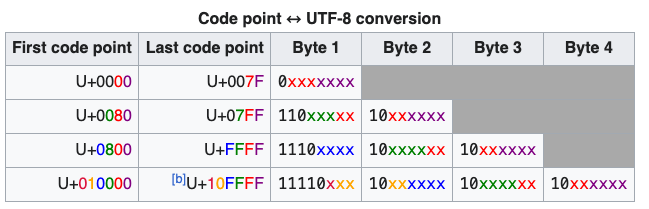

**Character ص example**:



The character `ص` code point is `U+0635` (1589 in decimal). If you try to represent this using binary presentation, it doesn't fit into 1 byte, you'll need to use 2 bytes.

Using 2 bytes, it yields the following `00000110 00110101`. Now, UTF-8 doesn't use conversion to bytes to encode code points. It has its own rules to do the encoding.

Now, if you look at the table, you see that `U+0635` falls between the range of `U+0080` and `U+07FF`. So, we have to use the rule in the second row to encode it using UTF-8.

The way to do this is to fill the `x` with the numbers in the binary representation starting from the right (copy-paste digit from the binary representation starting from the right):
- Before filling: [110]xxxxx [10]xxxxxx
- After filling: [110]11000 [10]110101. In hexadecimal, this yields `d8 b5`.




In [70]:
print(f"The byte 11011000 yields in hexadecimal: {hex(0b11011000)}")
print(f"The byte 10110101 yields in hexadecimal: {hex(0b10110101)}")

The byte 11011000 yields in hexadecimal: 0xd8
The byte 10110101 yields in hexadecimal: 0xb5


Now, this should match the result of the UTF-8 encoding of the character `ص` using Python

In [71]:
"ص".encode("utf-8")

b'\xd8\xb5'

The same rule can be applied to all the 4 ranges in order to go from a code point to its UTF-8 encoding.

At this step, I suggest you pick some characters from the unicode table page I've given you above and do the encoding manually.

**Note**: There is something that you should note at this step:
- Unicode allows us to go from a character to a code point
- The UTF-8 encoding (which is one of Unicode available encodings) allows us to go from a code point to a 1 to 4 bytes representation, depending on the character.

This yields the following trajectory: `Unicode character` <-> `Code point` -> `1 to 4 bytes representation`.

Now, if you take any 1 to 4 bytes number, it doesn't always map to a code point as it might not respect the rules specified in the wikipedia table above. For example, `11111111` (255 in decimal) corresponds to 1 byte but it's not a valid unicode encoding. This is because the rule specifies that all 1-byte encoded characters should start with a `0` and not a `1`.

### <a id='toc1_2_3_'></a>[A sentence example](#toc0_)

Let us now encode a whole sentence and see the result: `Hello there صفوان`

In [73]:
ex_sentence = "Hello there صفوان"

print(f"The UTF-8 encoding of the sentence '{ex_sentence}' is: {ex_sentence.encode('UTF-8')}")

The UTF-8 encoding of the sentence 'Hello there صفوان' is: b'Hello there \xd8\xb5\xd9\x81\xd9\x88\xd8\xa7\xd9\x86'


I hope you at least recognize the UTF-8 encoding of the character `ص`: `\xd8\xb5`

A question that might come to your mind upong seeing the result is why the hell we have characters like `H` in a bytes representation. This is something that has to do with the display of bytes in Python.

Python uses a mixed representation of bytes for readability:
- ASCII characters, even when encoded as bytes, are displayed in their readable form
- Non-ASCII characters, when encoded as bytes, are displayed in hexadecimal format

It's just a displaying matter !


## <a id='toc1_3_'></a>[BPE Tokenization [WIP]](#toc0_) [&#8593;](#toc0_)